In [52]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as ticker

# List of months used in the analysis
months = [
    202505,
    202506,
    202507,
    202508,
    202509,
    202510,
    202511,
    202512,
    202601,
    202602,
    202603,
    202604
]

month_list = [
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April"
]

In [2]:
# function to load the cleaned data files
def load_csv(month):
    return pd.read_csv(f"../cleaned_data/20260510-final/{month}_final.csv")

In [4]:
# function to compare both types of members
def compare_member_casual(df):
    return df.groupby('member_casual').size()

In [5]:
# function to compare the usage of both types of bikes
def compare_bike_usage(df):
    return df.groupby('rideable_type').size()

In [6]:
# function to compare both types of bikes grouped by membsership
def compare_bike_usage_by_membership(df):
    return df.groupby(['member_casual', 'rideable_type']).size()

In [7]:
# function to compare ride durations
def compare_ride_duration(df):
    df['ride_duration'] = pd.to_timedelta(df['ride_duration'])
    return df['ride_duration'].agg(['min', 'median', 'mean', 'max'])

In [8]:
# function to compare ride durations between membership
def compare_ride_duration_by_membership(df):
    df['ride_duration'] = pd.to_timedelta(df['ride_duration'])
    return df.groupby('member_casual')['ride_duration'].agg(['median', 'mean'])

In [9]:
# function to compare bike usage by weekday
def compare_bike_usage_by_weekday(df):
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    df['weekday'] = pd.Categorical(df['weekday'], categories=order, ordered=True)
    return df.groupby('weekday').size()

In [10]:
# function to compare bike usage by weekday and membership
def compare_bike_usage_by_weekday_and_membership(df):
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    df['weekday'] = pd.Categorical(df['weekday'], categories=order, ordered=True)
    return df.groupby(['member_casual', 'weekday']).size()

In [11]:
# Check seasonal differences in rides
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"Total no rides: {len(df)}")
    print("------------------------------------------------------------")    

Month: 202505
Total no rides: 340634
------------------------------------------------------------
Month: 202506
Total no rides: 446363
------------------------------------------------------------
Month: 202507
Total no rides: 494293
------------------------------------------------------------
Month: 202508
Total no rides: 515533
------------------------------------------------------------
Month: 202509
Total no rides: 467881
------------------------------------------------------------
Month: 202510
Total no rides: 417877
------------------------------------------------------------
Month: 202511
Total no rides: 234991
------------------------------------------------------------
Month: 202512
Total no rides: 96158
------------------------------------------------------------
Month: 202601
Total no rides: 97118
------------------------------------------------------------
Month: 202602
Total no rides: 147622
------------------------------------------------------------
Month: 202603
Total no

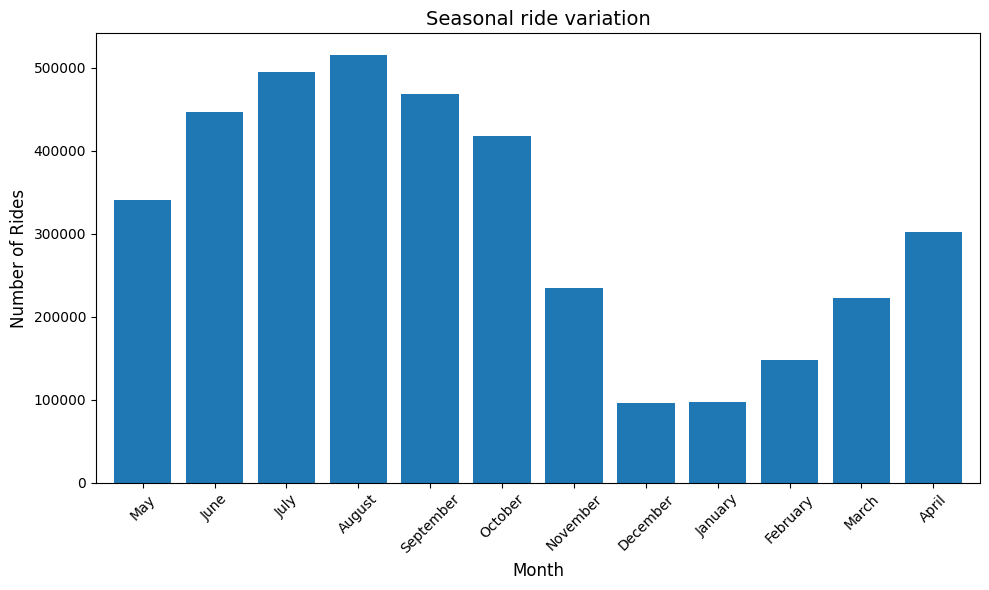

In [12]:
results = {}
index = 0

for month in months:
    df = load_csv(month)
    results[month_list[index]] = len(df)
    index += 1

plot_df = pd.DataFrame(results, index=['Total Rides']).T

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(kind='bar', ax=ax, width=0.8, legend=False)

ax.set_title('Seasonal ride variation', fontsize=14)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation.png")
plt.show()

In [13]:
# Check differences between bike types and membership
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"Member vs. Casual: {compare_member_casual(df)}")
    print(f"Classic vs. Electric: {compare_bike_usage(df)}")
    print(f"Membership & Bike Type: {compare_bike_usage_by_membership(df)}")
    print("-------------------------------------------------------------")

Month: 202505
Member vs. Casual: member_casual
casual    125635
member    214999
dtype: int64
Classic vs. Electric: rideable_type
classic_bike     185537
electric_bike    155097
dtype: int64
Membership & Bike Type: member_casual  rideable_type
casual         classic_bike      66868
               electric_bike     58767
member         classic_bike     118669
               electric_bike     96330
dtype: int64
-------------------------------------------------------------
Month: 202506
Member vs. Casual: member_casual
casual    193163
member    253200
dtype: int64
Classic vs. Electric: rideable_type
classic_bike     253115
electric_bike    193248
dtype: int64
Membership & Bike Type: member_casual  rideable_type
casual         classic_bike     109377
               electric_bike     83786
member         classic_bike     143738
               electric_bike    109462
dtype: int64
-------------------------------------------------------------
Month: 202507
Member vs. Casual: member_casual
cas

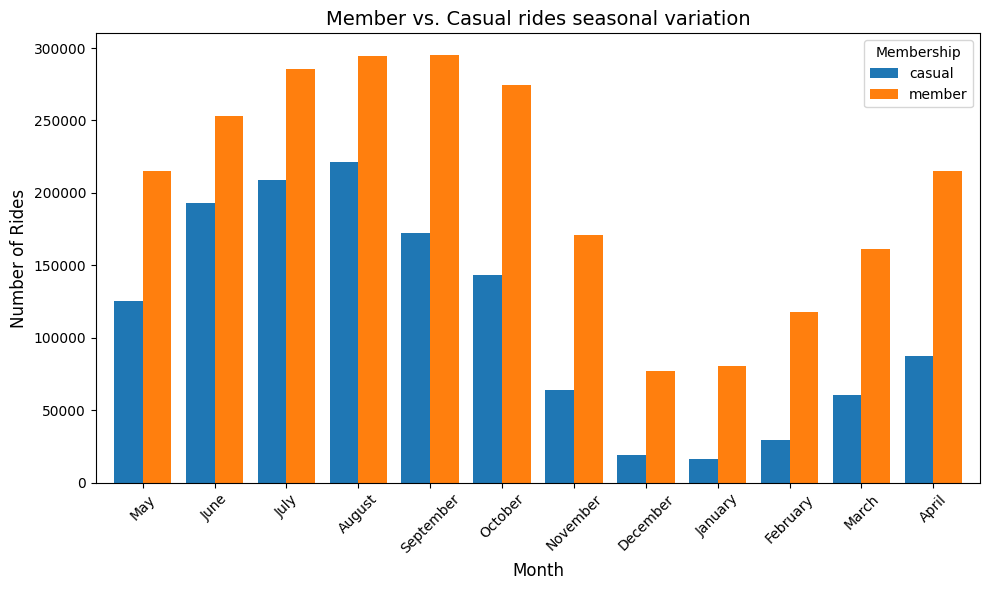

In [14]:
results = {}
index = 0

for month in months:
    df = load_csv(month)
    results[month_list[index]] = compare_member_casual(df)
    index += 1
    
plot_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Member vs. Casual rides seasonal variation', fontsize=14)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Membership')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_member_vs_casual.png")
plt.show()

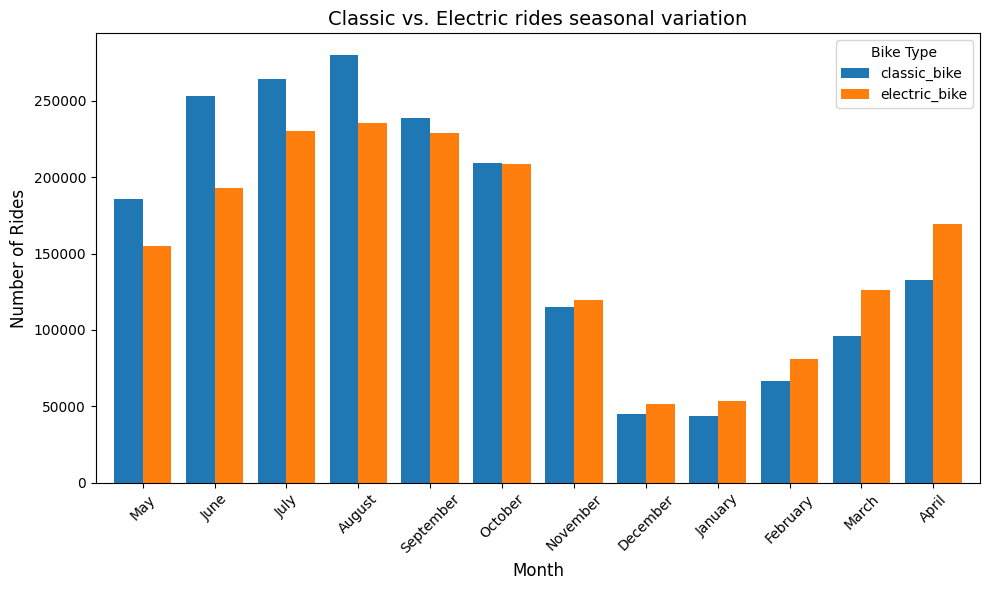

In [15]:
results = {}
index = 0

for month in months:
    df = load_csv(month)
    results[month_list[index]] = compare_bike_usage(df)
    index += 1
    
plot_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Classic vs. Electric rides seasonal variation', fontsize=14)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Bike Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_classic_vs_electric.png")
plt.show()

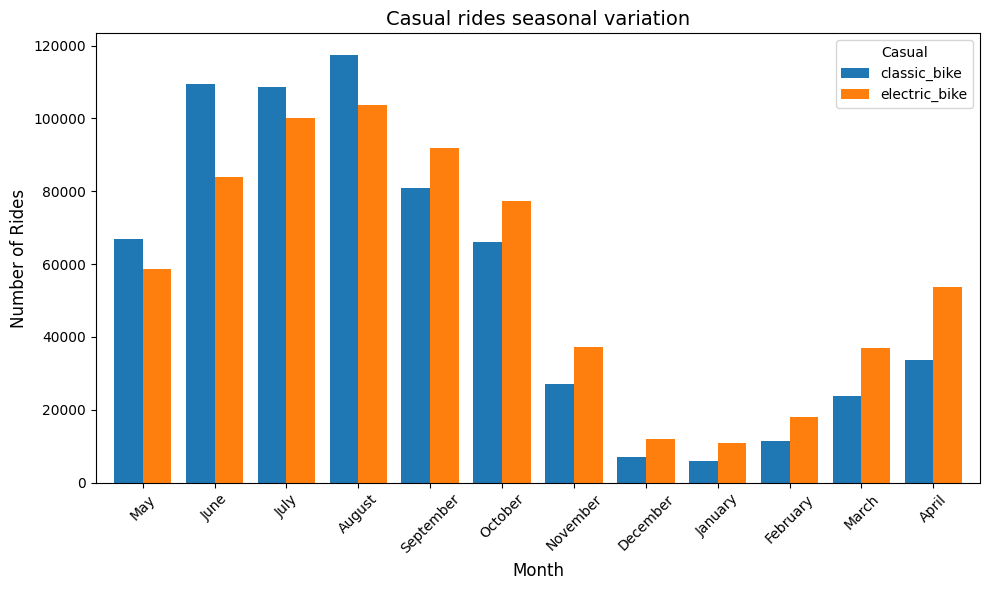

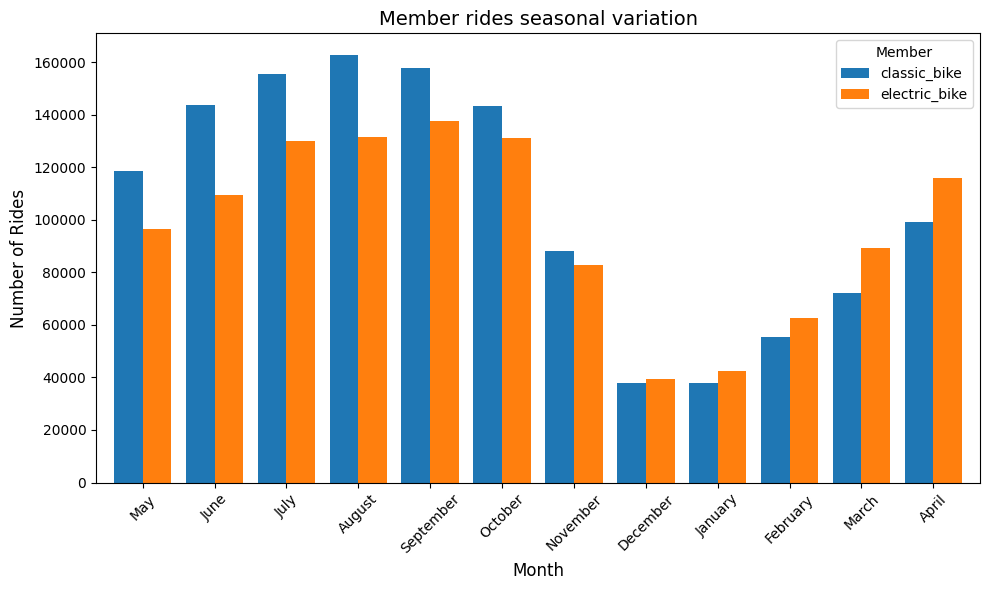

In [16]:
results = {}
index = 0

for month in months:
    df = load_csv(month)
    results[month_list[index]] = compare_bike_usage_by_membership(df)
    index += 1
    
plot_df = pd.DataFrame(results).T
plot_df_casual = plot_df['casual']
plot_df_member = plot_df['member']

fig, ax = plt.subplots(figsize=(10, 6))

plot_df_casual.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Casual rides seasonal variation', fontsize=14)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Casual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_casual.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

plot_df_member.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Member rides seasonal variation', fontsize=14)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Member')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_member.png")
plt.show()

In [17]:
# Check seasonal differences in ride duration
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"Ride duration:\n{compare_ride_duration(df)}")
    print("------------------------------------------------------------")

Month: 202505
Ride duration:
min      0 days 00:00:00.519000
median   0 days 00:10:07.826500
mean     0 days 00:16:15.825676
max      1 days 00:59:38.262000
Name: ride_duration, dtype: timedelta64[us]
------------------------------------------------------------
Month: 202506
Ride duration:
min      0 days 00:00:00.229000
median   0 days 00:11:20.275000
mean     0 days 00:18:07.268028
max      1 days 00:53:37.856000
Name: ride_duration, dtype: timedelta64[us]
------------------------------------------------------------
Month: 202507
Ride duration:
min      0 days 00:00:00.132000
median   0 days 00:11:04.610000
mean     0 days 00:17:59.643541
max      1 days 00:57:59.566000
Name: ride_duration, dtype: timedelta64[us]
------------------------------------------------------------
Month: 202508
Ride duration:
min      0 days 00:00:00.466000
median   0 days 00:11:17.861000
mean     0 days 00:17:58.308042
max      1 days 00:56:20.033000
Name: ride_duration, dtype: timedelta64[us]
-------------

In [18]:
# Check seasonal differences in ride duration by membership
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"Ride duration:\n{compare_ride_duration_by_membership(df)}")
    print("------------------------------------------------------------")

Month: 202505
Ride duration:
                              median                   mean
member_casual                                              
casual        0 days 00:13:21.522000 0 days 00:23:21.350586
member        0 days 00:08:47.439000 0 days 00:12:07.169534
------------------------------------------------------------
Month: 202506
Ride duration:
                              median                   mean
member_casual                                              
casual        0 days 00:14:27.962000 0 days 00:24:42.989322
member        0 days 00:09:34.794000 0 days 00:13:05.377380
------------------------------------------------------------
Month: 202507
Ride duration:
                              median                   mean
member_casual                                              
casual        0 days 00:14:01.870000 0 days 00:24:10.476211
member        0 days 00:09:32.061000 0 days 00:13:28.563875
------------------------------------------------------------
Month: 202

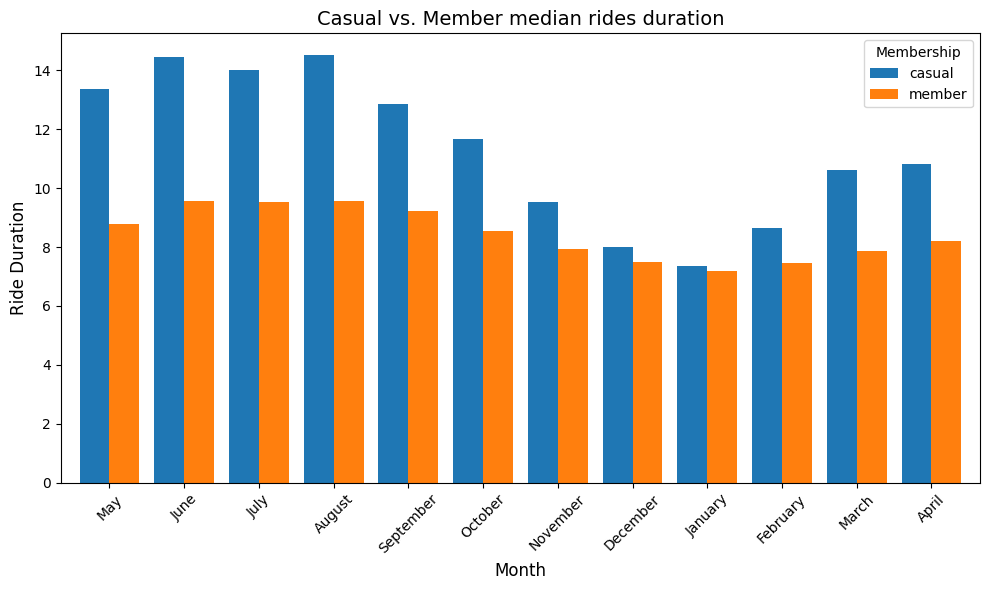

In [19]:
results = {}
index = 0
for month in months:
    df = load_csv(month)
    df['ride_duration'] = pd.to_timedelta(df['ride_duration'])/pd.Timedelta(minutes=1)
    results[month_list[index]] = df.groupby('member_casual')['ride_duration'].agg('median')
    index += 1

plot_df = pd.DataFrame(results).T
plot_df
fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Casual vs. Member median rides duration', fontsize=14)
ax.set_ylabel('Ride Duration', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Membership')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_duration_variation_casual_vs_member_median.png")
plt.show()

In [20]:
# Check seasonal differences among weekdays
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"{compare_bike_usage_by_weekday(df)}")
    print("------------------------------------------------------------")

Month: 202505
weekday
Monday       41449
Tuesday      43641
Wednesday    41888
Thursday     56360
Friday       60159
Saturday     59135
Sunday       38002
dtype: int64
------------------------------------------------------------
Month: 202506
weekday
Monday       70299
Tuesday      60846
Wednesday    48218
Thursday     63077
Friday       60920
Saturday     72837
Sunday       70166
dtype: int64
------------------------------------------------------------
Month: 202507
weekday
Monday       61581
Tuesday      82808
Wednesday    78072
Thursday     78144
Friday       63670
Saturday     69037
Sunday       60981
dtype: int64
------------------------------------------------------------
Month: 202508
weekday
Monday       56049
Tuesday      57738
Wednesday    67613
Thursday     66843
Friday       86672
Saturday     94012
Sunday       86606
dtype: int64
------------------------------------------------------------
Month: 202509
weekday
Monday       76535
Tuesday      78712
Wednesday    60053
Thurs

In [21]:
# Check seasonal differences among weekdays and between membership
for month in months:
    print(f"Month: {month}")
    df = load_csv(month)
    print(f"{compare_bike_usage_by_weekday_and_membership(df)}")
    print("------------------------------------------------------------")

Month: 202505
member_casual  weekday  
casual         Monday       14291
               Tuesday      12427
               Wednesday    11439
               Thursday     16918
               Friday       22904
               Saturday     29104
               Sunday       18552
member         Monday       27158
               Tuesday      31214
               Wednesday    30449
               Thursday     39442
               Friday       37255
               Saturday     30031
               Sunday       19450
dtype: int64
------------------------------------------------------------
Month: 202506
member_casual  weekday  
casual         Monday       25487
               Tuesday      21036
               Wednesday    16767
               Thursday     24621
               Friday       26829
               Saturday     41230
               Sunday       37193
member         Monday       44812
               Tuesday      39810
               Wednesday    31451
               Thursday     3845

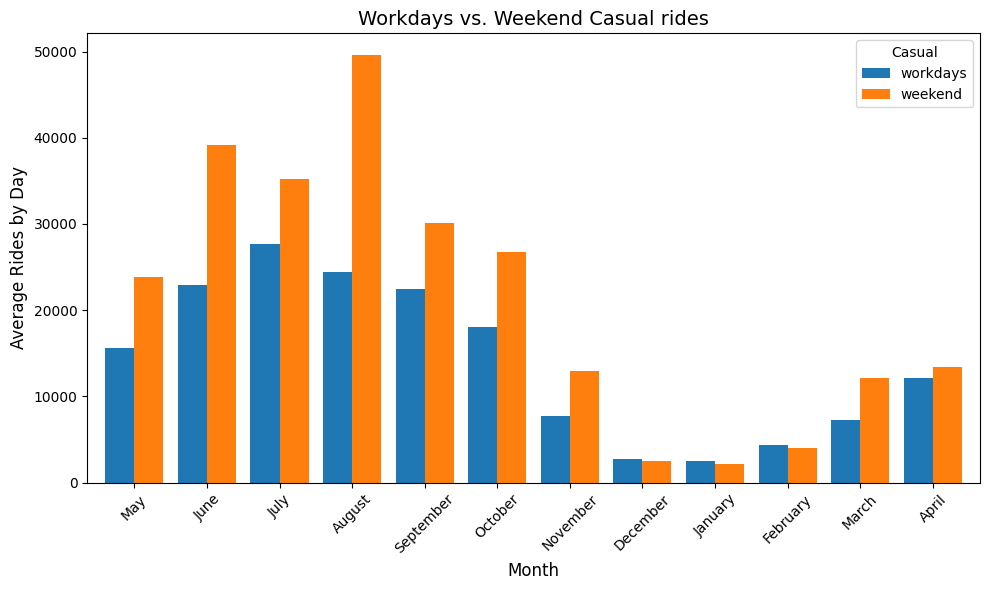

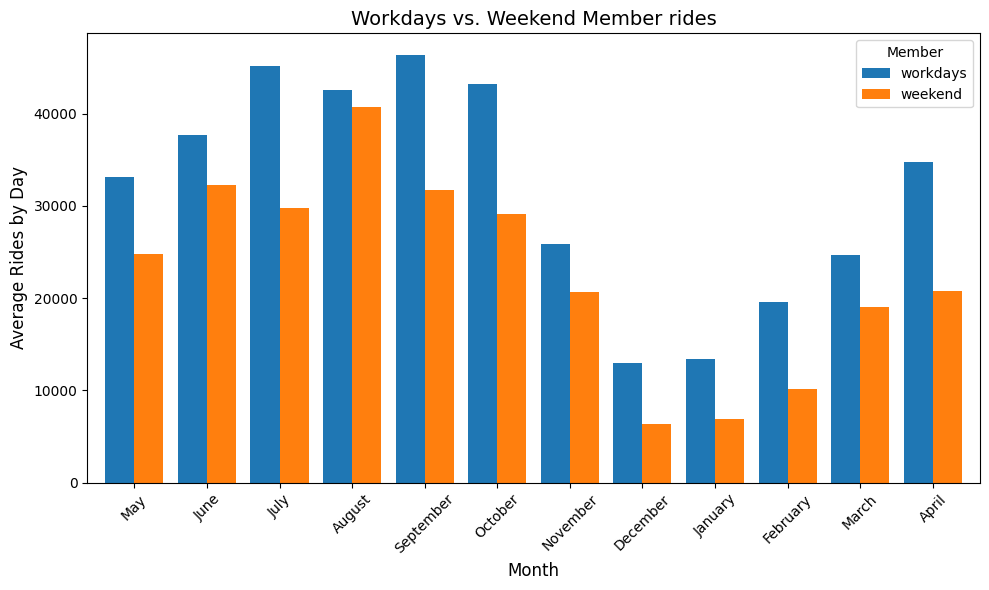

In [22]:
results = {}
index = 0

for month in months:
    df = load_csv(month)
    results[month_list[index]] = compare_bike_usage_by_weekday_and_membership(df)
    index += 1
    
plot_df = pd.DataFrame(results).T
plot_df_casual = plot_df['casual']
plot_df_member = plot_df['member']
plot_df_casual['workdays'] = plot_df_casual[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']].sum(axis=1)/5
plot_df_casual['weekend'] = plot_df_casual[['Saturday', 'Sunday']].sum(axis=1)/2
plot_df_member['workdays'] = plot_df_member[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']].sum(axis=1)/5
plot_df_member['weekend'] = plot_df_member[['Saturday', 'Sunday']].sum(axis=1)/2
    
fig, ax = plt.subplots(figsize=(10, 6))

plot_df_casual[['workdays', 'weekend']].plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Workdays vs. Weekend Casual rides', fontsize=14)
ax.set_ylabel('Average Rides by Day', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Casual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_workdays_vs_weekend_casual.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

plot_df_member[['workdays', 'weekend']].plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Workdays vs. Weekend Member rides', fontsize=14)
ax.set_ylabel('Average Rides by Day', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(title='Member')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/seasonal_ride_variation_workdays_vs_weekend_member.png")
plt.show()

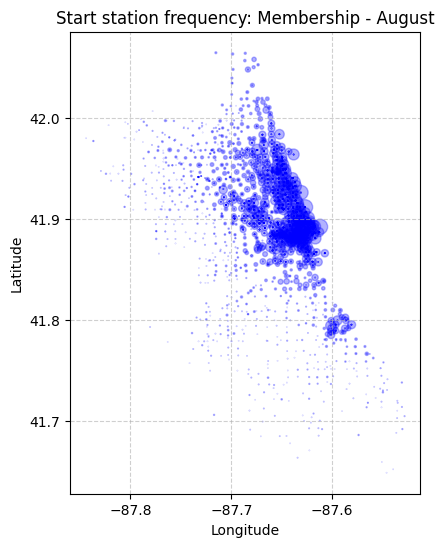

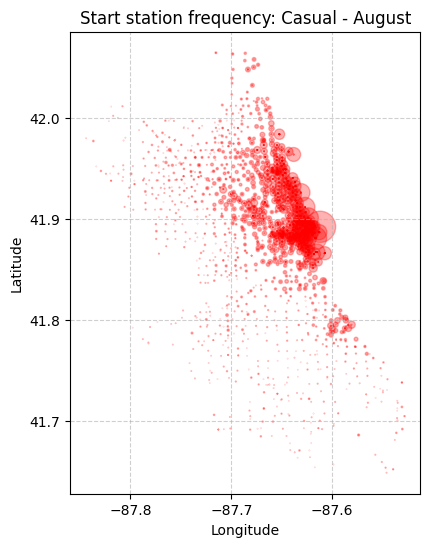

In [58]:
# Comparison between Membership and Casual riders starting points in August (summer reference)
df = load_csv(months[3])
mask = df['member_casual'] == 'member'
results = df[mask].groupby(['start_lng', 'start_lat']).size().reset_index(name='count')
plot_df = pd.DataFrame(results)
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['start_lng'], plot_df['start_lat'], alpha=0.3, s=plot_df['count'] * 0.05, color='blue')
plt.title('Start station frequency: Membership - August')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../plots/start_station_freq_member_august.png")
plt.show()

df = load_csv(months[3])
mask = df['member_casual'] == 'casual'
results = df[mask].groupby(['start_lng', 'start_lat']).size().reset_index(name='count')
plot_df = pd.DataFrame(results)
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['start_lng'], plot_df['start_lat'], alpha=0.3, s=plot_df['count'] * 0.05, color='red')
plt.title('Start station frequency: Casual - August')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../plots/start_station_freq_casual_august.png")
plt.show()

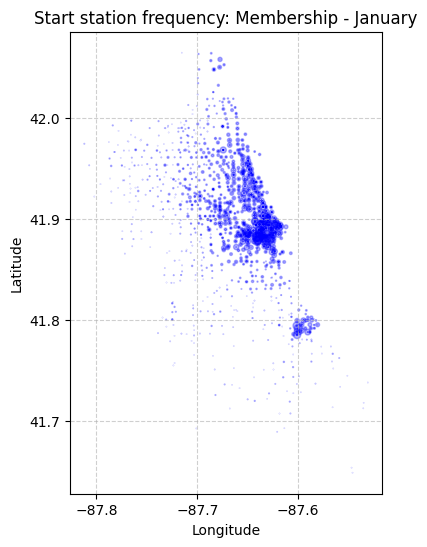

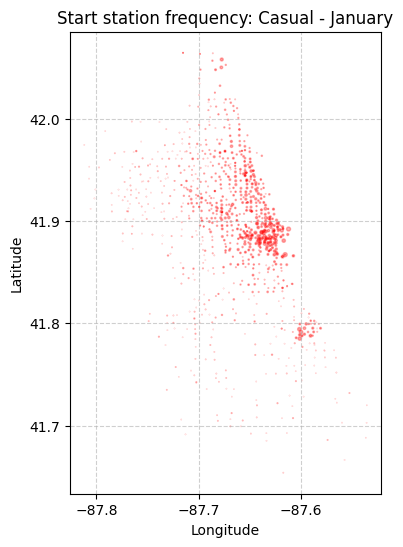

In [59]:
# Comparison between Membership and Casual riders starting points in January (winter reference)
df = load_csv(months[8])
mask = df['member_casual'] == 'member'
results = df[mask].groupby(['start_lng', 'start_lat']).size().reset_index(name='count')
plot_df = pd.DataFrame(results)
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['start_lng'], plot_df['start_lat'], alpha=0.3, s=plot_df['count'] * 0.05, color='blue')
plt.title('Start station frequency: Membership - January')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../plots/start_station_freq_member_january.png")
plt.show()

df = load_csv(months[8])
mask = df['member_casual'] == 'casual'
results = df[mask].groupby(['start_lng', 'start_lat']).size().reset_index(name='count')
plot_df = pd.DataFrame(results)
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['start_lng'], plot_df['start_lat'], alpha=0.3, s=plot_df['count'] * 0.05, color='red')
plt.title('Start station frequency: Casual - January')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../plots/start_station_freq_casual_january.png")
plt.show()